# DLinear on the M4 Dataset

This notebook implements **DLinear**, the decomposition-linear model from
*"Are Transformers Effective for Time Series Forecasting?"* (Zeng, Chen, Zhang, Xu — AAAI 2023,
[arXiv:2205.13504](https://arxiv.org/pdf/2205.13504.pdf)), and trains/evaluates it on the
**M4 forecasting competition dataset**.

**What DLinear does** (per the paper):
1. Decompose the input series into a *trend* component (moving-average) and a *seasonal/remainder*
   component (input minus trend) — the same decomposition used in Autoformer/FEDformer.
2. Apply one linear layer (`seq_len -> pred_len`) to each component independently.
3. Sum the two predictions.

That's the entire model — no attention, no nonlinearity, no positional encoding.

**Structure of this notebook**
1. Config & imports
2. Download / locate the M4 dataset
3. Data loading (per-series, ragged-length CSVs)
4. Model: `moving_avg`, `series_decomp`, `DLinear` (adapted from the authors' reference code)
5. Windowed `Dataset`/`DataLoader` for training on M4
6. Training loop
7. M4 evaluation metrics: SMAPE, MASE, OWA (vs. the Naive2 benchmark)
8. Qualitative plots

> Only one M4 frequency (e.g. `Monthly`) is trained at a time — set it in the CONFIG cell.
> Re-run the notebook once per frequency if you want results across all six M4 subsets.


In [12]:
# !pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached https://download-r2.pytorch.org/whl/cpu/torch-2.13.0%2Bcpu-cp310-cp310-manylinux_2_28_x86_64.whl (191.8 MB)
  Using cached https://download-r2.pytorch.org/whl/cpu/torchvision-0.28.0%2Bcpu-cp310-cp310-manylinux_2_28_x86_64.whl (1.8 MB)
  Using cached networkx-3.4.2-py3-none-any.whl (1.7 MB)
  Using cached https://download.pytorch.org/whl/jinja2-3.1.6-py3-none-any.whl (134 kB)
  Using cached fsspec-2026.4.0-py3-none-any.whl (203 kB)
  Using cached filelock-3.29.0-py3-none-any.whl (39 kB)
  Using cached https://download.pytorch.org/whl/setuptools-78.1.0-py3-none-any.whl (1.3 MB)
  Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
  Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
  Using cached https://download.pytorch.org/whl/markupsafe-3.0.3-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (20 kB)
  Attempting uninstall: setuptools
    Found existing installation: setuptools 59.6

In [13]:
import os
import csv
import math
import random
import urllib.request
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

SEED = 2023
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


## 1. Config

M4 has six frequencies, each with its own forecast horizon and seasonal period
(used later for the MASE metric). Pick one via `FREQUENCY`.

| Frequency | Horizon | Seasonal period (m) | # series (approx.) |
|---|---|---|---|
| Yearly    | 6  | 1  | 23,000 |
| Quarterly | 8  | 4  | 24,000 |
| Monthly   | 18 | 12 | 48,000 |
| Weekly    | 13 | 1  | 359 |
| Daily     | 14 | 1  | 4,227 |
| Hourly    | 48 | 24 | 414 |


In [2]:
FREQ_INFO = {
    "Yearly":    {"horizon": 6,  "period": 1},
    "Quarterly": {"horizon": 8,  "period": 4},
    "Monthly":   {"horizon": 18, "period": 12},
    "Weekly":    {"horizon": 13, "period": 1},
    "Daily":     {"horizon": 14, "period": 1},
    "Hourly":    {"horizon": 48, "period": 24},
}

@dataclass
class Config:
    frequency: str = "Monthly"          # one of FREQ_INFO keys
    data_dir: str = "./dataset/m4"       # where the M4 CSVs live / will be downloaded to
    seq_len_mult: int = 2                # input window = seq_len_mult * horizon
    moving_avg: int = 25                 # decomposition kernel size (must be < seq_len, odd is fine)
    individual: bool = False             # DLinear has channels=1 for M4, so this has no effect here
    batch_size: int = 256
    epochs: int = 20
    lr: float = 1e-3
    window_sampling_limit_mult: int = 10  # how far back into a series training windows may be sampled
    val_fraction: float = 0.05            # fraction of series held out for validation loss tracking
    early_stop_patience: int = 4

cfg = Config()
cfg.horizon = FREQ_INFO[cfg.frequency]["horizon"]
cfg.period = FREQ_INFO[cfg.frequency]["period"]
cfg.seq_len = cfg.seq_len_mult * cfg.horizon
cfg.pred_len = cfg.horizon
# moving_avg kernel must be smaller than seq_len for the padding scheme below
cfg.moving_avg = min(cfg.moving_avg, max(3, cfg.seq_len - 1) | 1)  # keep it odd-ish and < seq_len

print(cfg)


Config(frequency='Monthly', data_dir='./dataset/m4', seq_len_mult=2, moving_avg=25, individual=False, batch_size=256, epochs=20, lr=0.001, window_sampling_limit_mult=10, val_fraction=0.05, early_stop_patience=4)


## 2. Download the M4 dataset

The official M4 CSVs are hosted in the
[Mcompetitions/M4-methods](https://github.com/Mcompetitions/M4-methods) GitHub repo:

- `Dataset/M4-info.csv` — per-series metadata (frequency, horizon, etc.)
- `Dataset/Train/<Frequency>-train.csv` — training portion of every series (ragged length, zero-padded columns)
- `Dataset/Test/<Frequency>-test.csv` — the held-out horizon to forecast

If this environment has no internet access, download these three files yourself and place them in
`cfg.data_dir` (default `./dataset/m4/`), keeping the `Train/` and `Test/` subfolder names, then just
re-run this cell — it skips any file that's already present.


In [4]:
M4_BASE_URL = "https://raw.githubusercontent.com/Mcompetitions/M4-methods/master/Dataset"

def download_m4(cfg: Config):
    os.makedirs(os.path.join(cfg.data_dir, "Train"), exist_ok=True)
    os.makedirs(os.path.join(cfg.data_dir, "Test"), exist_ok=True)

    files = {
        os.path.join(cfg.data_dir, "M4-info.csv"): f"{M4_BASE_URL}/M4-info.csv",
        os.path.join(cfg.data_dir, "Train", f"{cfg.frequency}-train.csv"):
            f"{M4_BASE_URL}/Train/{cfg.frequency}-train.csv",
        os.path.join(cfg.data_dir, "Test", f"{cfg.frequency}-test.csv"):
            f"{M4_BASE_URL}/Test/{cfg.frequency}-test.csv",
    }

    for local_path, url in files.items():
        if os.path.exists(local_path):
            print(f"[skip] {local_path} already exists")
            continue
        try:
            print(f"Downloading {url} -> {local_path}")
            urllib.request.urlretrieve(url, local_path)
        except Exception as e:
            print(f"  !! Could not download {url}: {e}")
            print("  Please download this file manually and place it at the path above.")

download_m4(cfg)


[skip] ./dataset/m4/M4-info.csv already exists


## 3. Load the M4 series

Each row of `<Frequency>-train.csv` / `<Frequency>-test.csv` is one series (`V1, V2, ...` columns,
right-padded with blanks for shorter series). We load each series as a 1-D numpy array with the
padding stripped off.


In [5]:
def load_m4_split(csv_path):
    """Load an M4 Train or Test CSV into a list of 1-D float32 numpy arrays (one per series)
    plus the list of series ids (row order preserved)."""
    series, ids = [], []
    with open(csv_path, encoding="latin-1") as f:
        reader = csv.reader(f)
        header = next(reader)
        for row in reader:
            ids.append(row[0])
            vals = [v for v in row[1:] if v.strip() != ""]
            series.append(np.asarray(vals, dtype=np.float32))
    return series, ids

train_path = os.path.join(cfg.data_dir, "Train", f"{cfg.frequency}-train.csv")
test_path = os.path.join(cfg.data_dir, "Test", f"{cfg.frequency}-test.csv")

train_series, train_ids = load_m4_split(train_path)
test_series, test_ids = load_m4_split(test_path)

assert train_ids == test_ids, "Train/Test series order mismatch"
n_series = len(train_series)
print(f"{cfg.frequency}: {n_series} series loaded")
print("Example lengths (train):", [len(s) for s in train_series[:5]])
print("Test horizon per series (should all equal cfg.horizon):",
      set(len(s) for s in test_series[:200]))


Monthly: 48000 series loaded
Example lengths (train): [469, 469, 469, 82, 112]
Test horizon per series (should all equal cfg.horizon): {18}


## 4. Model — moving average decomposition + DLinear

This mirrors the reference implementation (`DLinear.py` / Autoformer's `series_decomp`):

- `moving_avg`: an `AvgPool1d` over the time axis, replicate-padded at both ends so the output
  length matches the input length.
- `series_decomp`: `trend = moving_avg(x)`, `seasonal = x - trend`.
- `DLinearM4`: one linear layer `seq_len -> pred_len` for the trend, one for the seasonal
  component; predictions are summed. Since M4 series are univariate (channels = 1), the
  `individual` flag from the original multivariate model doesn't matter here — we keep a single
  shared linear layer per component.


In [14]:
class moving_avg(nn.Module):
    """Moving average block to highlight the trend of a time series (replicate padding
    at both ends so output length == input length)."""
    def __init__(self, kernel_size, stride=1):
        super().__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)

    def forward(self, x):
        # x: [B, L, C]
        front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        end = x[:, -1:, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        x = torch.cat([front, x, end], dim=1)
        x = self.avg(x.permute(0, 2, 1))
        return x.permute(0, 2, 1)


class series_decomp(nn.Module):
    """Series decomposition block: trend (moving average) + seasonal (residual)."""
    def __init__(self, kernel_size):
        super().__init__()
        self.moving_avg = moving_avg(kernel_size, stride=1)

    def forward(self, x):
        trend = self.moving_avg(x)
        seasonal = x - trend
        return seasonal, trend


class DLinearM4(nn.Module):
    """DLinear specialised to univariate M4 series (channels = 1)."""
    def __init__(self, seq_len, pred_len, moving_avg_kernel=25):
        super().__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.decompsition = series_decomp(moving_avg_kernel)

        self.Linear_Seasonal = nn.Linear(seq_len, pred_len)
        self.Linear_Trend = nn.Linear(seq_len, pred_len)

        # Match the paper's initialization: start as a uniform (1/seq_len) moving-average-like map
        with torch.no_grad():
            self.Linear_Seasonal.weight.copy_((1 / seq_len) * torch.ones(pred_len, seq_len))
            self.Linear_Trend.weight.copy_((1 / seq_len) * torch.ones(pred_len, seq_len))

    def forward(self, x):
        # x: [B, seq_len, 1]
        seasonal_init, trend_init = self.decompsition(x)
        seasonal_init, trend_init = seasonal_init.permute(0, 2, 1), trend_init.permute(0, 2, 1)
        seasonal_output = self.Linear_Seasonal(seasonal_init)
        trend_output = self.Linear_Trend(trend_init)
        out = seasonal_output + trend_output          # [B, 1, pred_len]
        return out.permute(0, 2, 1)                    # [B, pred_len, 1]

model = DLinearM4(cfg.seq_len, cfg.pred_len, cfg.moving_avg).to(device)
print(model)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


DLinearM4(
  (decompsition): series_decomp(
    (moving_avg): moving_avg(
      (avg): AvgPool1d(kernel_size=(25,), stride=(1,), padding=(0,))
    )
  )
  (Linear_Seasonal): Linear(in_features=36, out_features=18, bias=True)
  (Linear_Trend): Linear(in_features=36, out_features=18, bias=True)
)
Trainable parameters: 1332


## 5. Windowed training dataset

M4 series have very different lengths, so we don't pre-slice a fixed set of windows. Instead,
following the standard M4 sampling scheme used for N-BEATS/DLinear-style benchmarks:

- For **training**, on every access we pick a random cut point inside the series (limited to the
  most recent `window_sampling_limit` points so the model mostly sees recent history) and take the
  `seq_len` points before it as input and the `pred_len` points after it as target. Series shorter
  than the requested window are left-zero-padded, with a mask marking the padded positions.
- For **evaluation**, the input is always the *last* `seq_len` points of the training portion, and
  the target is the real M4 test horizon.


In [15]:
class M4TrainDataset(Dataset):
    def __init__(self, series_list, seq_len, pred_len, sampling_limit_mult=10):
        self.series = series_list
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.limit_mult = sampling_limit_mult

    def __len__(self):
        return len(self.series)

    def __getitem__(self, idx):
        s = self.series[idx]
        L = len(s)
        window_limit = max(self.pred_len + 1, self.limit_mult * self.pred_len)
        low = max(1, L - window_limit)
        high = max(low + 1, L)
        cut = np.random.randint(low, high)

        insample = np.zeros(self.seq_len, dtype=np.float32)
        insample_mask = np.zeros(self.seq_len, dtype=np.float32)
        window = s[max(0, cut - self.seq_len):cut]
        if len(window) > 0:
            insample[-len(window):] = window
            insample_mask[-len(window):] = 1.0

        outsample = np.zeros(self.pred_len, dtype=np.float32)
        outsample_mask = np.zeros(self.pred_len, dtype=np.float32)
        target = s[cut:cut + self.pred_len]
        outsample[:len(target)] = target
        outsample_mask[:len(target)] = 1.0

        return (torch.from_numpy(insample).unsqueeze(-1),
                torch.from_numpy(outsample).unsqueeze(-1),
                torch.from_numpy(insample_mask).unsqueeze(-1),
                torch.from_numpy(outsample_mask).unsqueeze(-1))


class M4EvalDataset(Dataset):
    """One sample per series: input = last seq_len points of train, target = real test horizon."""
    def __init__(self, train_list, test_list, seq_len, pred_len):
        self.train = train_list
        self.test = test_list
        self.seq_len = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.train)

    def __getitem__(self, idx):
        s = self.train[idx]
        insample = np.zeros(self.seq_len, dtype=np.float32)
        window = s[-self.seq_len:]
        insample[-len(window):] = window
        target = self.test[idx][:self.pred_len].astype(np.float32)
        return torch.from_numpy(insample).unsqueeze(-1), torch.from_numpy(target).unsqueeze(-1), idx


## 6. Train / validation split & DataLoaders

We hold out a small fraction of *series* for tracking validation loss during training (early
stopping). Final scoring in Section 7 always uses the full evaluation set (all series, real M4
test horizons).


In [16]:
indices = np.arange(n_series)
np.random.shuffle(indices)
n_val = max(1, int(cfg.val_fraction * n_series))
val_idx, train_idx = indices[:n_val], indices[n_val:]

train_subset = [train_series[i] for i in train_idx]
val_subset = [train_series[i] for i in val_idx]

train_ds = M4TrainDataset(train_subset, cfg.seq_len, cfg.pred_len, cfg.window_sampling_limit_mult)
val_ds = M4TrainDataset(val_subset, cfg.seq_len, cfg.pred_len, cfg.window_sampling_limit_mult)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False)

print(f"Train series: {len(train_subset)}  Val series: {len(val_subset)}")


Train series: 45600  Val series: 2400


## 7. Training loop

We minimise masked MAE between prediction and target (only over non-padded positions), which is a
robust, scale-reasonable loss for M4's very heterogeneous series magnitudes.


In [17]:
def masked_mae(pred, target, mask):
    diff = torch.abs(pred - target) * mask
    denom = mask.sum().clamp(min=1.0)
    return diff.sum() / denom

def run_epoch(loader, model, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, total_batches = 0.0, 0
    for insample, outsample, insample_mask, outsample_mask in loader:
        insample = insample.to(device)
        outsample = outsample.to(device)
        outsample_mask = outsample_mask.to(device)

        if is_train:
            optimizer.zero_grad()
        pred = model(insample)
        loss = masked_mae(pred, outsample, outsample_mask)
        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        total_batches += 1
    return total_loss / max(1, total_batches)

optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)

best_val = float("inf")
patience_ctr = 0
best_state = None

for epoch in range(1, cfg.epochs + 1):
    train_loss = run_epoch(train_loader, model, optimizer)
    with torch.no_grad():
        val_loss = run_epoch(val_loader, model, optimizer=None)

    print(f"Epoch {epoch:02d} | train MAE {train_loss:.4f} | val MAE {val_loss:.4f}")

    if val_loss < best_val - 1e-5:
        best_val = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= cfg.early_stop_patience:
            print(f"Early stopping at epoch {epoch} (best val MAE {best_val:.4f})")
            break

if best_state is not None:
    model.load_state_dict(best_state)


Epoch 01 | train MAE 728.5100 | val MAE 617.7570
Epoch 02 | train MAE 595.5570 | val MAE 603.2481
Epoch 03 | train MAE 578.1951 | val MAE 580.7773
Epoch 04 | train MAE 578.4893 | val MAE 598.5792
Epoch 05 | train MAE 580.6437 | val MAE 574.2495
Epoch 06 | train MAE 575.9753 | val MAE 597.8533
Epoch 07 | train MAE 584.6755 | val MAE 579.4457
Epoch 08 | train MAE 580.8283 | val MAE 569.3762
Epoch 09 | train MAE 581.0178 | val MAE 603.9248
Epoch 10 | train MAE 577.4934 | val MAE 589.4644
Epoch 11 | train MAE 575.8423 | val MAE 567.3420
Epoch 12 | train MAE 574.9498 | val MAE 588.6247
Epoch 13 | train MAE 581.2616 | val MAE 581.9057
Epoch 14 | train MAE 578.8526 | val MAE 563.5057
Epoch 15 | train MAE 575.8559 | val MAE 579.9431
Epoch 16 | train MAE 580.8851 | val MAE 582.4963
Epoch 17 | train MAE 579.8252 | val MAE 574.2257
Epoch 18 | train MAE 575.0907 | val MAE 592.4785
Early stopping at epoch 18 (best val MAE 563.5057)


## 8. M4 evaluation metrics — SMAPE, MASE, OWA

These are the exact metrics used in the M4 competition:

- **SMAPE** = `200/h * sum(|F - A| / (|A| + |F|))`
- **MASE** = `mean(|F - A|) / mean(|Y_t - Y_{t-m}|)`, where the denominator is the in-sample
  seasonal-naive error on the *training* portion of the series (`m` = seasonal period, e.g. 12 for
  Monthly).
- **OWA** (Overall Weighted Average) = `0.5 * (SMAPE / SMAPE_naive2 + MASE / MASE_naive2)`, scored
  against the M4 **Naive2** benchmark (seasonally-adjusted naive forecast). OWA < 1 means the model
  beats Naive2 on average.


In [18]:
def smape(forecast, actual):
    # forecast, actual: [N, h]
    denom = np.abs(actual) + np.abs(forecast)
    denom = np.where(denom == 0, 1.0, denom)
    return 200.0 * np.mean(np.abs(forecast - actual) / denom, axis=1)

def mase(forecast, actual, insample, period):
    # in-sample seasonal-naive denominator, per series
    masep = np.mean(np.abs(insample[:, period:] - insample[:, :-period]), axis=1)
    masep = np.where(masep == 0, 1e-8, masep)
    return np.mean(np.abs(forecast - actual), axis=1) / masep

def seasonal_naive_forecast(insample_list, horizon, period):
    """M4's simple seasonal-naive forecast, used as the base for Naive2."""
    out = np.zeros((len(insample_list), horizon), dtype=np.float32)
    for i, s in enumerate(insample_list):
        if period > 1 and len(s) >= period:
            last_season = s[-period:]
            reps = int(np.ceil(horizon / period))
            out[i] = np.tile(last_season, reps)[:horizon]
        else:
            out[i] = s[-1] if len(s) > 0 else 0.0
    return out


In [19]:
eval_ds = M4EvalDataset(train_series, test_series, cfg.seq_len, cfg.pred_len)
eval_loader = DataLoader(eval_ds, batch_size=512, shuffle=False)

model.eval()
all_preds = np.zeros((n_series, cfg.pred_len), dtype=np.float32)
all_targets = np.zeros((n_series, cfg.pred_len), dtype=np.float32)

with torch.no_grad():
    for insample, target, idx in eval_loader:
        insample = insample.to(device)
        pred = model(insample).cpu().numpy().squeeze(-1)
        all_preds[idx.numpy()] = pred
        all_targets[idx.numpy()] = target.numpy().squeeze(-1)

# Pad/truncate insample series to a common length for the vectorised MASE calc
max_len = max(len(s) for s in train_series)
insample_matrix = np.zeros((n_series, max_len), dtype=np.float32)
for i, s in enumerate(train_series):
    insample_matrix[i, -len(s):] = s

smape_scores = smape(all_preds, all_targets)
mase_scores = mase(all_preds, all_targets, insample_matrix, cfg.period)

naive2_preds = seasonal_naive_forecast(train_series, cfg.pred_len, cfg.period)
smape_naive2 = smape(naive2_preds, all_targets)
mase_naive2 = mase(naive2_preds, all_targets, insample_matrix, cfg.period)

owa = 0.5 * (smape_scores.mean() / smape_naive2.mean() + mase_scores.mean() / mase_naive2.mean())

print(f"=== DLinear on M4-{cfg.frequency} (horizon={cfg.horizon}) ===")
print(f"SMAPE : {smape_scores.mean():.3f}   (Naive2: {smape_naive2.mean():.3f})")
print(f"MASE  : {mase_scores.mean():.3f}   (Naive2: {mase_naive2.mean():.3f})")
print(f"OWA   : {owa:.3f}   (<1.0 means beating Naive2)")


=== DLinear on M4-Monthly (horizon=18) ===
SMAPE : 14.130   (Naive2: 15.988)
MASE  : 12.674   (Naive2: 14.797)
OWA   : 0.870   (<1.0 means beating Naive2)


## 9. Qualitative check — plot a few forecasts


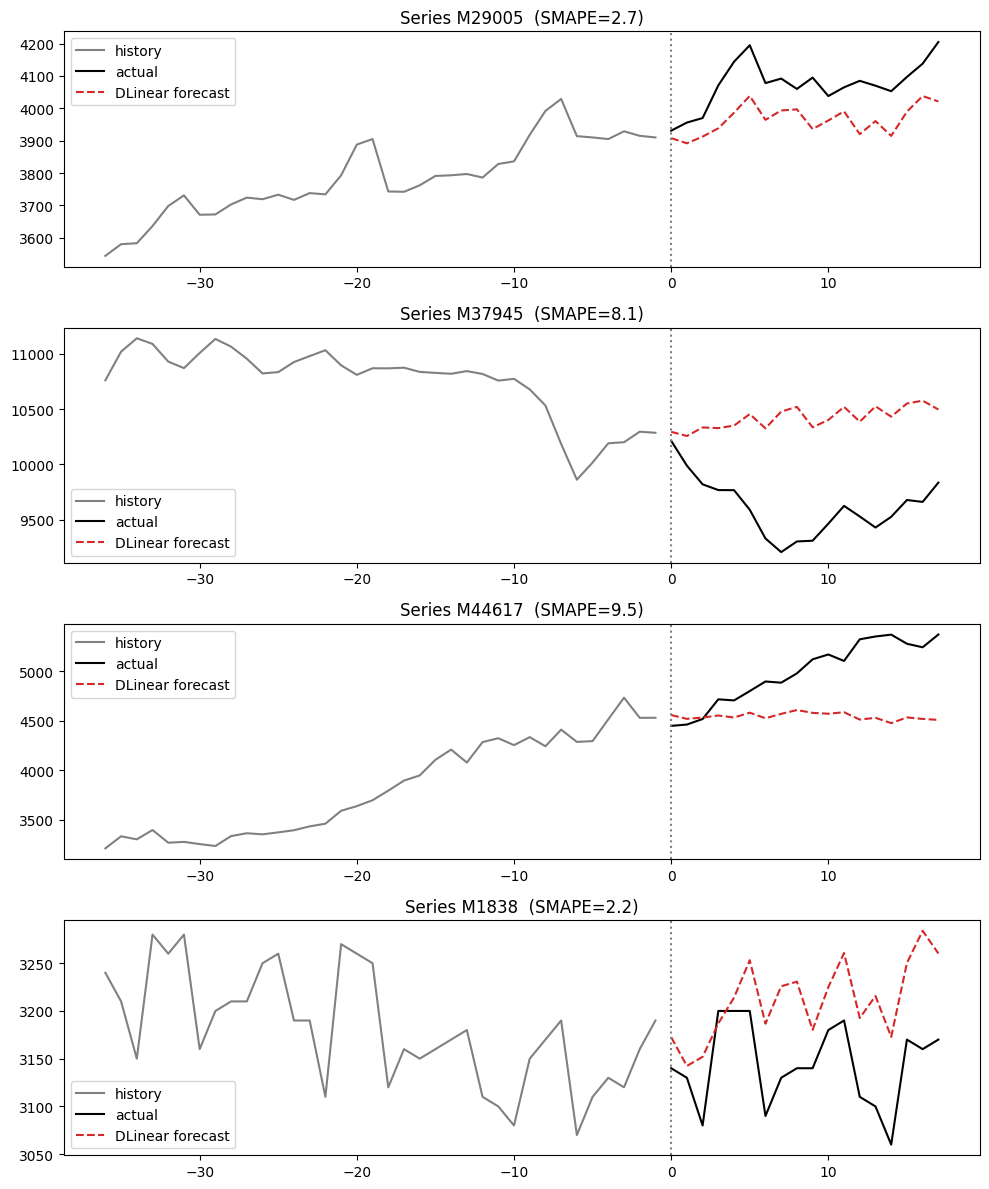

In [20]:
n_plots = 4
plot_idx = np.random.choice(n_series, size=n_plots, replace=False)

fig, axes = plt.subplots(n_plots, 1, figsize=(10, 3 * n_plots))
if n_plots == 1:
    axes = [axes]

for ax, i in zip(axes, plot_idx):
    hist = train_series[i][-cfg.seq_len:]
    hist_x = np.arange(-len(hist), 0)
    fut_x = np.arange(0, cfg.pred_len)

    ax.plot(hist_x, hist, label="history", color="gray")
    ax.plot(fut_x, all_targets[i], label="actual", color="black")
    ax.plot(fut_x, all_preds[i], label="DLinear forecast", color="tab:red", linestyle="--")
    ax.axvline(0, color="gray", linestyle=":")
    ax.set_title(f"Series {train_ids[i]}  (SMAPE={smape_scores[i]:.1f})")
    ax.legend()

plt.tight_layout()
plt.show()


## Notes

- **Reference SMAPE/OWA scores on M4-Monthly** from the DLinear paper (Table 2 covers different
  benchmarks; M4 itself was popularized by the N-BEATS/M4 competition literature) are typically in
  the SMAPE ≈ 12–13 range for strong linear/statistical models, with the M4 competition winner
  (a hybrid ES-RNN) around SMAPE ≈ 11.7 and OWA ≈ 0.821 on Monthly. Use these only as a rough sanity
  check — exact comparability depends on training budget and hyperparameters.
- To reproduce results across **all six frequencies**, change `cfg.frequency` in the Config cell and
  re-run from Section 2 onward (or wrap Sections 2–8 in a loop over `FREQ_INFO.keys()`).
- `cfg.moving_avg` should stay smaller than `cfg.seq_len`; for very short-horizon frequencies
  (Weekly/Daily) you may want a smaller kernel (e.g. 5–7) since `seq_len` itself is small.
- This notebook trains one shared linear model per frequency (channels = 1, so the paper's
  `individual` flag is moot for M4's univariate series).
